# Doc Agent — CodeT5+ 770M Fine-tuning on CodeSearchNet Java
### Autonomous Multi-Agent Platform

| Step | Description | Time (P100) |
|------|-------------|------------|
| 1 | Setup + imports | 3 min |
| 2 | Load dataset (local mount) | 1 min |
| 3 | Filter + tokenise 50k examples | 2 min |
| 4 | Load model + LoRA | 1 min |
| 5 | Train 3 epochs | ~6 hrs |
| 6 | Evaluate — ROUGE / BLEU / BERTScore | 15 min |
| 7 | Visualisations | 2 min |
| 8 | Save + zip + HF Hub push | 5 min |

## Step 1 — Setup

In [1]:
import os, re, gc, json, glob, warnings, logging
import subprocess, sys

os.environ["CUDA_VISIBLE_DEVICES"]      = "0"
os.environ["TOKENIZERS_PARALLELISM"]    = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"]   = "expandable_segments:True"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip(
    "transformers==4.44.0",
    "peft==0.10.0",
    "accelerate==0.29.0",
    "datasets>=2.19.0",
    "evaluate", "rouge_score", "bert_score", "sacrebleu",
    "sentencepiece", "huggingface_hub>=0.22.0",
    "seaborn>=0.13.0", "plotly>=5.20.0",
)
print("All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.3/297.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.9 MB/s eta 0:00:00
All packages installed


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm.auto import tqdm

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback, set_seed,
)
from peft import LoraConfig, TaskType, get_peft_model
import evaluate as hf_evaluate

set_seed(42)

plt.rcParams.update({
    "figure.facecolor":"#0d1117","axes.facecolor":"#161b22",
    "axes.edgecolor":"#30363d","axes.labelcolor":"#c9d1d9",
    "text.color":"#c9d1d9","xtick.color":"#8b949e",
    "ytick.color":"#8b949e","grid.color":"#21262d",
    "grid.alpha":0.6,"font.family":"monospace","figure.dpi":110,
})
PALETTE = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657",
           "#79c0ff","#56d364","#ff7b72","#bc8cff","#ffb77a"]

# ── Constants ─────────────────────────────────────────────────────────────
MODEL_NAME     = "Salesforce/codet5p-770m"
MAX_INPUT_LEN  = 512
MAX_TARGET_LEN = 128
MAX_TRAIN      = 50000
MAX_VALID      = 5000
OUTPUT_DIR     = "/kaggle/working/doc_agent_final"
LOG_DIR        = "/kaggle/working/logs"
DATA_ROOT      = "/kaggle/input/datasets/adityapandit07/codesearchnet-java-dataset"

# ── Best hyperparameters from Optuna HPO ──────────────────────────────────
BEST_LR         = 0.0007193314150910524
BEST_LORA_R     = 8
BEST_LORA_ALPHA = 32
BEST_BATCH      = 4
BEST_GRAD_ACC   = 8

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,    exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"\nTraining config:")
print(f"  LR={BEST_LR:.2e} | r={BEST_LORA_R} | alpha={BEST_LORA_ALPHA}")
print(f"  Batch={BEST_BATCH} | GradAcc={BEST_GRAD_ACC} | EffBatch={BEST_BATCH*BEST_GRAD_ACC}")
print(f"  Train={MAX_TRAIN:,} examples | 3 epochs | ~6 hrs on P100")

2026-03-17 00:44:56.222746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773708296.409952      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773708296.466892      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773708296.915066      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773708296.915110      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773708296.915113      55 computation_placer.cc:177] computation placer alr

PyTorch  : 2.9.0+cu126
Device   : cuda
GPU      : Tesla P100-PCIE-16GB
VRAM     : 17.1 GB

Training config:
  LR=7.19e-04 | r=8 | alpha=32
  Batch=4 | GradAcc=8 | EffBatch=32
  Train=50,000 examples | 3 epochs | ~6 hrs on P100


## Step 2 — Load Dataset

In [3]:
def load_jsonl(pattern):
    rows = []
    for path in sorted(glob.glob(pattern, recursive=True)):
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line: rows.append(json.loads(line))
    return rows

raw = {}
for split, key in [("train","train"),("valid","validation"),("test","test")]:
    rows = load_jsonl(f"{DATA_ROOT}/**/*java*{split}*.jsonl")
    if not rows: rows = load_jsonl(f"{DATA_ROOT}/**/*{split}*.jsonl")
    if rows: raw[key] = rows

if raw:
    print("Loaded from Kaggle local mount")
else:
    from datasets import load_dataset
    print("Downloading from HuggingFace Hub ...")
    ds = load_dataset("code_search_net", "java")
    raw = {
        "train":      [dict(r) for r in ds["train"]],
        "validation": [dict(r) for r in ds["validation"]],
        "test":       [dict(r) for r in ds["test"]],
    }
    print("Downloaded from HuggingFace Hub")

def normalise(row):
    return {
        "code":      (row.get("code") or row.get("whole_func_string") or "").strip(),
        "docstring": (row.get("docstring") or row.get("func_documentation_string") or "").strip(),
    }

raw_norm = {split: [normalise(r) for r in rows] for split, rows in raw.items()}

for split, rows in raw_norm.items():
    print(f"  {split:12s}: {len(rows):>7,} examples")

Loaded from Kaggle local mount
  train       : 454,451 examples
  validation  :  15,328 examples
  test        :  26,909 examples


## Step 3 — Filter + Tokenise

In [4]:
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print(f"Vocab size: {tokenizer.vocab_size:,}")

Loading tokenizer: Salesforce/codet5p-770m


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Vocab size: 32,100


In [5]:
def quality_filter(row):
    code = row["code"].strip()
    doc  = row["docstring"].strip()
    if len(code) < 30 or len(doc) < 5 or len(doc) > 2000:      return False
    if "@deprecated" in doc.lower():                             return False
    if "TODO" in code or "FIXME" in code:                        return False
    if not re.search(r"(public|private|protected|static).*\(", code): return False
    if re.match(r".*\b(get|set|is)[A-Z]\w*\s*\(", code):
        if len(code.split("\n")) <= 5: return False
    return True

def format_input(code):
    return f"Generate Javadoc for the following Java method:\n{code.strip()}"

print("Filtering ...")
filtered = {}
for split, rows in raw_norm.items():
    kept = [r for r in rows if quality_filter(r)]
    filtered[split] = kept
    print(f"  {split:12s}: {len(rows):>7,} -> {len(kept):>7,}  ({len(kept)/len(rows)*100:.1f}% kept)")

Filtering ...
  train       : 454,451 -> 412,798  (90.8% kept)
  validation  :  15,328 ->  13,966  (91.1% kept)
  test        :  26,909 ->  24,194  (89.9% kept)


In [6]:
def tokenise_dataset(rows, desc=""):
    input_ids_all, attn_all, labels_all = [], [], []
    for row in tqdm(rows, desc=desc, ncols=80):
        enc = tokenizer(format_input(row["code"]),
                        max_length=MAX_INPUT_LEN, truncation=True)
        lab = tokenizer(text_target=row["docstring"].strip(),
                        max_length=MAX_TARGET_LEN, truncation=True)
        input_ids_all.append(enc["input_ids"])
        attn_all.append(enc["attention_mask"])
        labels_all.append(lab["input_ids"])
    return Dataset.from_dict({
        "input_ids":      input_ids_all,
        "attention_mask": attn_all,
        "labels":         labels_all,
    })

train_ds = tokenise_dataset(filtered["train"][:MAX_TRAIN],      "Tokenising train")
valid_ds = tokenise_dataset(filtered["validation"][:MAX_VALID], "Tokenising valid")
test_ds  = tokenise_dataset(filtered["test"][:MAX_VALID],       "Tokenising test")

print(f"\nFinal sizes  Train:{len(train_ds):,}  Valid:{len(valid_ds):,}  Test:{len(test_ds):,}")
print(f"Steps/epoch : {len(train_ds)//(BEST_BATCH*BEST_GRAD_ACC):,}")

Tokenising train:   0%|                               | 0/50000 [00:00<?, ?it/s]

Tokenising valid:   0%|                                | 0/5000 [00:00<?, ?it/s]

Tokenising test:   0%|                                 | 0/5000 [00:00<?, ?it/s]


Final sizes  Train:50,000  Valid:5,000  Test:5,000
Steps/epoch : 1,562


## Step 4 — Load Model + LoRA

In [7]:
gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()

print("Loading base model ...")
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=BEST_LORA_R, lora_alpha=BEST_LORA_ALPHA,
    lora_dropout=0.05,
    target_modules=["q","v"],
    bias="none",
)
model = get_peft_model(base_model, lora_cfg)
model.enable_input_require_grads()

# Cast LoRA weights to fp32 — prevents "Attempting to unscale FP16 gradients"
for param in model.parameters():
    if param.requires_grad:
        param.data = param.data.float()

model.print_trainable_parameters()

Loading base model ...


config.json:   0%|          | 0.00/770 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

trainable params: 2,359,296 || all params: 739,998,720 || trainable%: 0.31882433526371506


## Step 5 — Train

In [10]:
rouge_metric = hf_evaluate.load("rouge")

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple): preds = preds[0]
    preds  = np.clip(preds,  0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, tokenizer.vocab_size - 1)
    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds  = [p.strip() if p.strip() else "empty" for p in decoded_preds]
    decoded_labels = [l.strip() if l.strip() else "empty" for l in decoded_labels]
    result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {k: round(v, 4) for k, v in result.items()}

In [11]:
TRAINING_LOG = []

class MetricsCallback(EarlyStoppingCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            TRAINING_LOG.append({
                "epoch":     state.epoch,
                "eval_loss": metrics.get("eval_loss"),
                "rougeL":    metrics.get("eval_rougeL"),
                "rouge1":    metrics.get("eval_rouge1"),
                "rouge2":    metrics.get("eval_rouge2"),
            })
        super().on_evaluate(args, state, control, metrics=metrics, **kwargs)

collator = DataCollatorForSeq2Seq(
    tokenizer, model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=BEST_BATCH,
    per_device_eval_batch_size=BEST_BATCH,
    gradient_accumulation_steps=BEST_GRAD_ACC,
    learning_rate=BEST_LR,
    warmup_steps=200,
    weight_decay=0.01,
    fp16=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,
    logging_dir=LOG_DIR,
    logging_steps=100,
    report_to="none",
    seed=42,
    dataloader_num_workers=2,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[MetricsCallback(early_stopping_patience=2)],
)

print("Starting training ...")
print(f"  {len(train_ds):,} examples | 3 epochs | eff. batch {BEST_BATCH*BEST_GRAD_ACC}")
train_result = trainer.train()

print("\nTraining complete")
print(f"  Steps   : {train_result.global_step}")
print(f"  Loss    : {train_result.training_loss:.4f}")
print(f"  Runtime : {train_result.metrics['train_runtime']/60:.1f} min")

# ── AUTO SAVE immediately after training ──────────────────────────────────
import shutil
print("\nAuto-saving model ...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
shutil.make_archive("/kaggle/working/doc_agent_final","zip",
                    "/kaggle/working","doc_agent_final")
zip_mb = os.path.getsize("/kaggle/working/doc_agent_final.zip")/1e6
print(f"Saved + zipped: {zip_mb:.1f} MB")
print("Download: Kaggle Output tab -> doc_agent_final.zip")

Starting training ...
  50,000 examples | 3 epochs | eff. batch 32


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
0,1.538600,1.824944,0.318900,0.139400,0.275700,0.304300
2,1.369300,1.854330,0.321600,0.139500,0.276000,0.306400



Training complete
  Steps   : 4686
  Loss    : 1.5007
  Runtime : 620.0 min

Auto-saving model ...
Saved + zipped: 62.0 MB
Download: Kaggle Output tab -> doc_agent_final.zip


## Step 6 — Evaluation

In [14]:
# Fast evaluation — greedy decoding, no beam search, 200 samples only
from transformers import AutoModelForSeq2SeqLM
import numpy as np

model.eval()
N = 200
test_subset = test_ds.select(range(N))

pred_ids_list  = []
label_ids_list = []

for i in range(0, N, 8):
    batch = test_subset.select(range(i, min(i+8, N)))
    
    # Pad sequences to same length within batch
    input_ids_batch = [torch.tensor(x) for x in batch["input_ids"]]
    attn_batch      = [torch.tensor(x) for x in batch["attention_mask"]]
    
    input_ids_padded = torch.nn.utils.rnn.pad_sequence(
        input_ids_batch, batch_first=True,
        padding_value=tokenizer.pad_token_id
    ).to(model.device)
    attn_padded = torch.nn.utils.rnn.pad_sequence(
        attn_batch, batch_first=True, padding_value=0
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids=input_ids_padded,
            attention_mask=attn_padded,
            max_new_tokens=MAX_TARGET_LEN,
            num_beams=1,
            early_stopping=True,
        )
    pred_ids_list.extend(out.cpu().numpy().tolist())
    label_ids_list.extend(batch["labels"])

# Decode
pred_ids_list  = [np.clip(p, 0, tokenizer.vocab_size-1) for p in pred_ids_list]
label_ids_list = [np.where(np.array(l) != -100, np.array(l), tokenizer.pad_token_id)
                  for l in label_ids_list]
label_ids_list = [np.clip(l, 0, tokenizer.vocab_size-1) for l in label_ids_list]

predictions = tokenizer.batch_decode(pred_ids_list,  skip_special_tokens=True)
references  = tokenizer.batch_decode(label_ids_list, skip_special_tokens=True)
predictions = [p.strip() if p.strip() else "empty" for p in predictions]
references  = [r.strip() if r.strip() else "empty" for r in references]

# ROUGE
rouge_metric = hf_evaluate.load("rouge")
result = rouge_metric.compute(predictions=predictions, references=references, use_stemmer=True)
r1 = round(result["rouge1"], 4)
r2 = round(result["rouge2"], 4)
rL = round(result["rougeL"], 4)

# BLEU
sacrebleu  = hf_evaluate.load("sacrebleu")
bleu_score = sacrebleu.compute(
    predictions=predictions,
    references=[[r] for r in references]
)["score"]

# BERTScore
bert_f1 = None
try:
    bs = hf_evaluate.load("bertscore").compute(
        predictions=predictions, references=references,
        lang="en", model_type="distilbert-base-uncased"
    )
    bert_f1 = float(np.mean(bs["f1"]))
except Exception as e:
    print(f"BERTScore skipped: {e}")

print("\nFinal evaluation summary (200 test examples)")
print(f"  ROUGE-1   : {r1:.4f}")
print(f"  ROUGE-2   : {r2:.4f}")
print(f"  ROUGE-L   : {rL:.4f}")
print(f"  BLEU      : {bleu_score:.2f}")
if bert_f1: print(f"  BERTScore : {bert_f1:.4f}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


Final evaluation summary (200 test examples)
  ROUGE-1   : 0.2625
  ROUGE-2   : 0.0920
  ROUGE-L   : 0.2012
  BLEU      : 4.59
  BERTScore : 0.7644


In [15]:
# Qualitative examples
print("\nQualitative examples (first 5)")
for i in range(5):
    src = tokenizer.decode(test_subset["input_ids"][i], skip_special_tokens=True)
    src = src.replace("Generate Javadoc for the following Java method:","").strip()
    print(f"\n[{i+1}] Code      : {src[:100]} ...")
    print(f"    Reference : {references[i][:120]}")
    print(f"    Generated : {predictions[i][:120]}")


Qualitative examples (first 5)

[1] Code      : protected final void fastPathOrderedEmit(U value, boolean delayError, Disposable disposable) {
      ...
    Reference : Makes sure the fast-path emits in order.
@param value the value to emit or queue up
@param delayError if true, errors ar
    Generated : Fast path ordered emit.

@param value the value
@param delayError the delay error
@param disposable the disposable

[2] Code      : @CheckReturnValue
    @NonNull
    @SchedulerSupport(SchedulerSupport.NONE)
    public static <T> Ob ...
    Reference : Mirrors the one ObservableSource in an Iterable of several ObservableSources that first either emits an item or sends
a 
    Generated : Creates an Observable that emits all the items from the specified sources.

@param sources the sources to emit items fro

[3] Code      : @SuppressWarnings("unchecked")
    @CheckReturnValue
    @NonNull
    @SchedulerSupport(SchedulerSup ...
    Reference : Mirrors the one ObservableSource in an array

## Step 7 — Visualisations

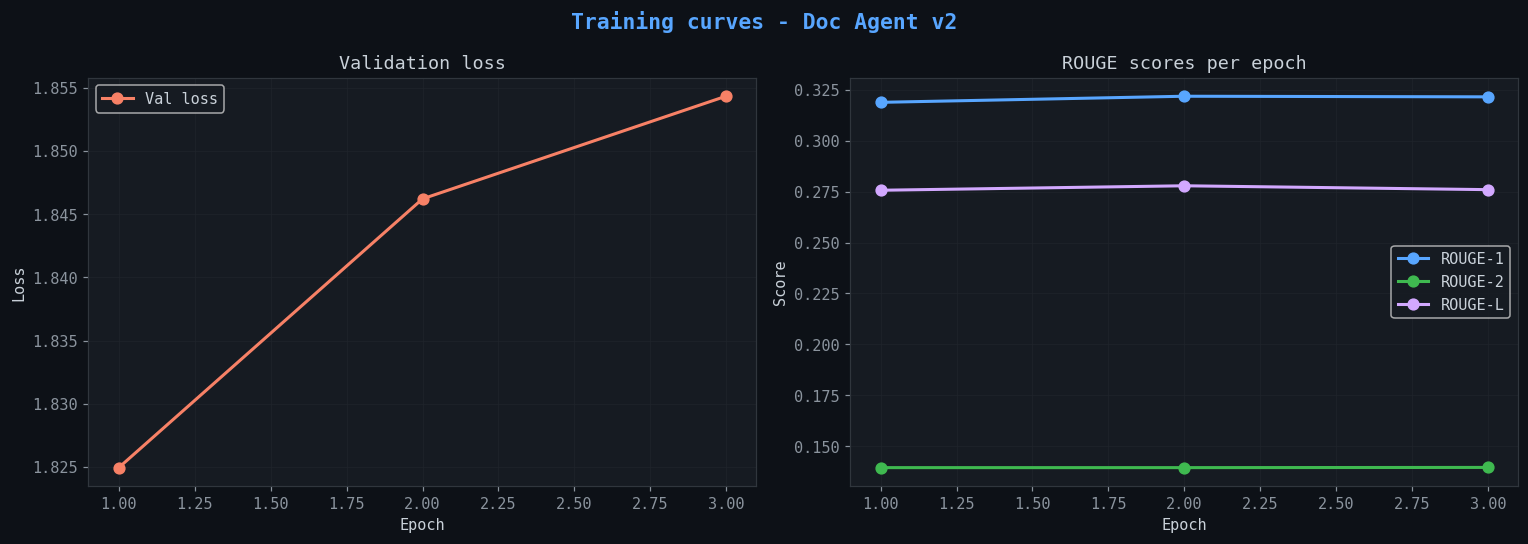

Training curves saved


In [16]:
log_df = pd.DataFrame(TRAINING_LOG)

if len(log_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training curves - Doc Agent v2", color="#58a6ff",
                 fontsize=14, fontweight="bold")
    axes[0].plot(log_df["epoch"], log_df["eval_loss"],
                 "o-", color=PALETTE[2], lw=2, ms=7, label="Val loss")
    axes[0].set_title("Validation loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].grid(True); axes[0].legend()
    for col, label, color in [
        ("rouge1","ROUGE-1",PALETTE[0]),
        ("rouge2","ROUGE-2",PALETTE[1]),
        ("rougeL","ROUGE-L",PALETTE[3]),
    ]:
        if col in log_df.columns:
            axes[1].plot(log_df["epoch"], log_df[col],
                         "o-", color=color, lw=2, ms=7, label=label)
    axes[1].set_title("ROUGE scores per epoch")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].grid(True); axes[1].legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Training curves saved")
else:
    print("No training log captured")

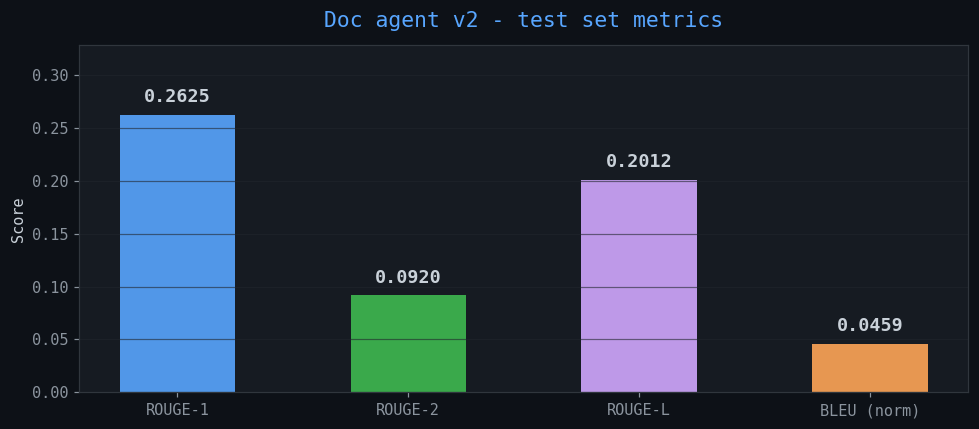

Metrics chart saved


In [17]:
# Metrics bar chart
fig, ax = plt.subplots(figsize=(9,4))
fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#161b22")
names  = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU (norm)"]
vals   = [r1, r2, rL, bleu_score/100]
colors = [PALETTE[0],PALETTE[1],PALETTE[3],PALETTE[4]]
bars   = ax.bar(names, vals, color=colors, width=0.5, alpha=0.9)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f"{v:.4f}",
            ha="center", va="bottom", color="#c9d1d9",
            fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals)*1.25)
ax.set_title("Doc agent v2 - test set metrics",
             color="#58a6ff", fontsize=14, pad=12)
ax.set_ylabel("Score"); ax.grid(axis="y", color="#21262d", alpha=0.6)
for spine in ax.spines.values(): spine.set_edgecolor("#30363d")
plt.tight_layout()
plt.savefig("/kaggle/working/metrics_bar.png", dpi=130, bbox_inches="tight")
plt.show()
print("Metrics chart saved")

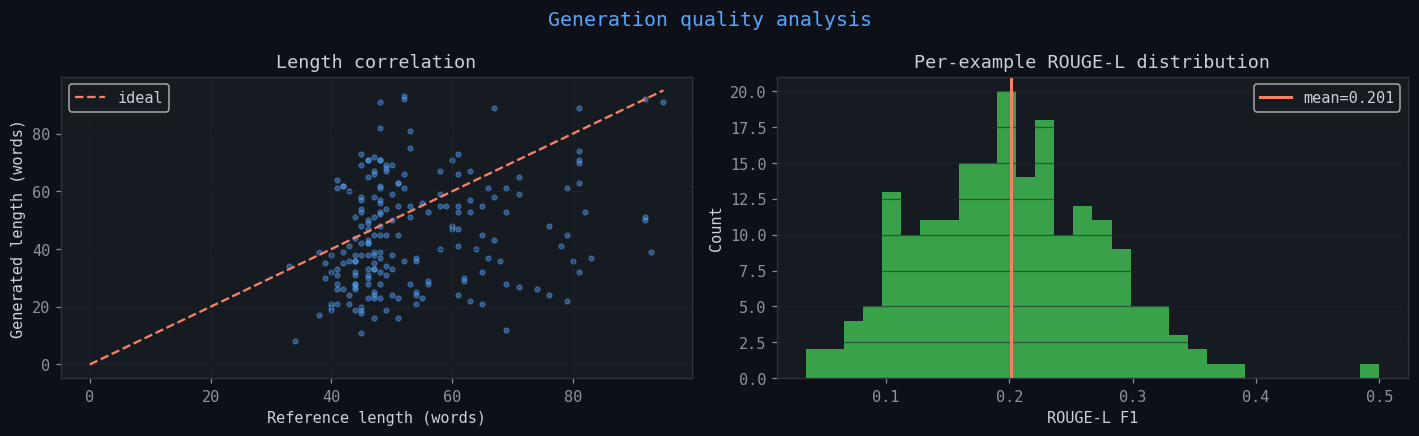

Quality chart saved


In [18]:
# Per-example ROUGE-L distribution
from rouge_score import rouge_scorer as rs_lib
scorer = rs_lib.RougeScorer(["rougeL"], use_stemmer=True)
per_rougel = [scorer.score(ref,pred)["rougeL"].fmeasure
              for ref, pred in zip(references, predictions)]

fig, axes = plt.subplots(1, 2, figsize=(13,4))
fig.suptitle("Generation quality analysis", color="#58a6ff", fontsize=13)

pred_lens = [len(p.split()) for p in predictions]
ref_lens  = [len(r.split()) for r in references]
axes[0].scatter(ref_lens, pred_lens, alpha=0.4, s=10, c=PALETTE[0])
max_l = max(max(ref_lens), max(pred_lens))
axes[0].plot([0,max_l],[0,max_l], color=PALETTE[2], lw=1.5,
             ls="--", label="ideal")
axes[0].set_xlabel("Reference length (words)")
axes[0].set_ylabel("Generated length (words)")
axes[0].set_title("Length correlation")
axes[0].legend(); axes[0].grid(True)

axes[1].hist(per_rougel, bins=30, color=PALETTE[1], alpha=0.85, edgecolor="none")
axes[1].axvline(np.mean(per_rougel), color=PALETTE[2], lw=2,
                label=f"mean={np.mean(per_rougel):.3f}")
axes[1].set_title("Per-example ROUGE-L distribution")
axes[1].set_xlabel("ROUGE-L F1"); axes[1].set_ylabel("Count")
axes[1].legend(); axes[1].grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/generation_quality.png", dpi=130, bbox_inches="tight")
plt.show()
print("Quality chart saved")

## Step 8 — Save + Zip + HuggingFace Hub

In [19]:
import shutil

# Save evaluation summary JSON
summary = {
    "version":        "v2",
    "base_model":     MODEL_NAME,
    "dataset":        "CodeSearchNet Java",
    "train_examples": len(train_ds),
    "hyperparameters": {
        "lr": BEST_LR, "lora_r": BEST_LORA_R,
        "lora_alpha": BEST_LORA_ALPHA,
        "batch_size": BEST_BATCH,
        "grad_accum": BEST_GRAD_ACC,
        "epochs": 3,
    },
    "test_metrics": {
        "rouge1": round(r1,4), "rouge2": round(r2,4),
        "rougeL": round(rL,4), "bleu":   round(bleu_score,2),
        "bertscore": round(bert_f1,4) if bert_f1 else None,
    },
}
with open(f"{OUTPUT_DIR}/evaluation_summary.json","w") as f:
    json.dump(summary, f, indent=2)

# Re-zip with evaluation summary included
shutil.make_archive("/kaggle/working/doc_agent_final","zip",
                    "/kaggle/working","doc_agent_final")
zip_mb = os.path.getsize("/kaggle/working/doc_agent_final.zip")/1e6
print(f"Final zip: {zip_mb:.1f} MB")
print("Download: Kaggle Output tab -> doc_agent_final.zip")

Final zip: 62.0 MB
Download: Kaggle Output tab -> doc_agent_final.zip


In [20]:
# HuggingFace Hub push — needs HUGGINGFACE_TOKEN in Kaggle Secrets
from huggingface_hub import HfApi, login, create_repo

HF_TOKEN   = None
HF_REPO_ID = None

try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HUGGINGFACE_TOKEN")
    print("HuggingFace token loaded")
except Exception as e:
    print(f"No HF token ({e}) - skipping Hub push")
    print("Zip download still available in Output tab")

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    api        = HfApi()
    username   = api.whoami()["name"]
    HF_REPO_ID = f"{username}/doc-agent-codet5p-java-v2"
    create_repo(HF_REPO_ID, repo_type="model", private=True, exist_ok=True)
    with open(f"{OUTPUT_DIR}/README.md","w") as f:
        f.write(
            f"# Doc Agent v2 - CodeT5+ 770M + LoRA (Java)\n\n"
            f"| Metric | Score |\n|--------|-------|\n"
            f"| ROUGE-1 | {r1:.4f} |\n"
            f"| ROUGE-2 | {r2:.4f} |\n"
            f"| ROUGE-L | {rL:.4f} |\n"
            f"| BLEU | {bleu_score:.2f} |\n"
        )
    api.upload_folder(
        folder_path=OUTPUT_DIR, repo_id=HF_REPO_ID,
        repo_type="model",
        commit_message="Doc agent v2 - CodeSearchNet Java 50k, 3 epochs",
    )
    print(f"Uploaded -> https://huggingface.co/{HF_REPO_ID}")

No HF token (Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 112372035 and label HUGGINGFACE_TOKEN.'], 'error': {'code': 5}, 'wasSuccessful': False}.) - skipping Hub push
Zip download still available in Output tab


In [21]:
print("=" * 55)
print("ALL DONE")
print("=" * 55)
print(f"  ROUGE-1   : {r1:.4f}")
print(f"  ROUGE-2   : {r2:.4f}")
print(f"  ROUGE-L   : {rL:.4f}")
print(f"  BLEU      : {bleu_score:.2f}")
if bert_f1: print(f"  BERTScore : {bert_f1:.4f}")
print()
print("Download:")
print("  Kaggle Output tab -> doc_agent_final.zip")
if HF_REPO_ID:
    print(f"  https://huggingface.co/{HF_REPO_ID}")
print()
print("Local setup:")
print("  1. Unzip doc_agent_final.zip")
print("  2. Copy to  models/doc_agent_final/")
print("  3. python main.py --file SimpleTest.java --mode both")

ALL DONE
  ROUGE-1   : 0.2625
  ROUGE-2   : 0.0920
  ROUGE-L   : 0.2012
  BLEU      : 4.59
  BERTScore : 0.7644

Download:
  Kaggle Output tab -> doc_agent_final.zip

Local setup:
  1. Unzip doc_agent_final.zip
  2. Copy to  models/doc_agent_final/
  3. python main.py --file SimpleTest.java --mode both
